# Activity-Based Hospitalization Risk from Accelerometry
NHANES 2005 | Biomedical Informatics

Minute-level hip accelerometry for adults 50+ linked to hospitalization records.
Goal: build activity trajectory profiles and assess hospitalization risk using
survival analysis and a Cox proportional hazards model.

1. Exploratory Data Analysis
2. Trajectory Feature Engineering
3. Risk Stratification and Kaplan-Meier Survival
4. Cox Proportional Hazards Model
5. Clinical Translation — Step Count Threshold
6. Activity Trajectory Prediction


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

try:
    from lifelines import KaplanMeierFitter, CoxPHFitter
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lifelines', '-q'])
    from lifelines import KaplanMeierFitter, CoxPHFitter

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

MASTER_PATH = '2005_master.csv'
AGG_PATH    = '2005_patient_aggregated.csv'

print('Loading master (15M rows)...')
master = pd.read_csv(MASTER_PATH)
agg    = pd.read_csv(AGG_PATH)
print('master:', master.shape, '| agg:', agg.shape)


Loading master (15M rows)...
master: (15383678, 18) | agg: (1528, 16)


In [40]:
def check_group_quality(df, cols, label=''):
    """Flag NaN counts and 3x-IQR outliers.
    Skips outlier detection on categorical columns (nunique <= 10)
    and zero-inflated columns (IQR = 0)."""
    print('Data Quality Check' + (' — ' + label if label else ''))
    print('-' * 50)
    issues = 0
    for col in cols:
        if col not in df.columns:
            print('  SKIP: ' + col + ' not found')
            continue
        n_nan    = int(df[col].isna().sum())
        pct_nan  = round(n_nan / len(df) * 100, 2)
        n_unique = int(df[col].nunique())
        if n_unique > 10:
            q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
            iqr    = q3 - q1
            if iqr > 0:
                n_out = int(((df[col] < q1 - 3 * iqr) | (df[col] > q3 + 3 * iqr)).sum())
                tag   = ''
            else:
                n_out = 0
                tag   = '(zero-inflated — outlier check skipped)'
        else:
            n_out = 0
            tag   = '(categorical — outlier check skipped)'
        flags = (' [NaN!!]' if n_nan > 0 else '') + (' [outliers]' if n_out > 0 else '')
        print('  ' + col.ljust(24) + 'NaN=' + str(n_nan) + ' (' + str(pct_nan) + '%)   Outliers=' + str(n_out) + '  ' + tag + flags)
        if n_nan > 0 or n_out > 0:
            issues += 1
    print('Result: ' + (str(issues) + ' column(s) flagged' if issues else 'All clear'))
    print()


## Part 1 — Exploratory Data Analysis

We look at when during the day people are active and whether hospitalized patients show
a different activity rhythm. We also check how step count and sedentary time relate to
clinical measurements — BMI, waist circumference, blood pressure — and how activity
patterns change across age groups.


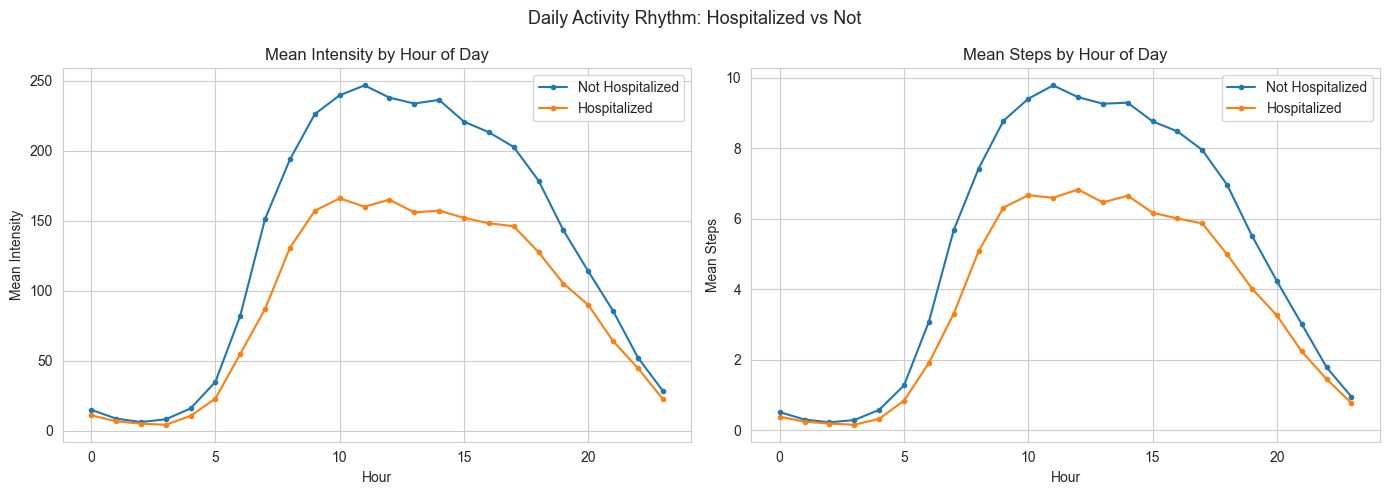

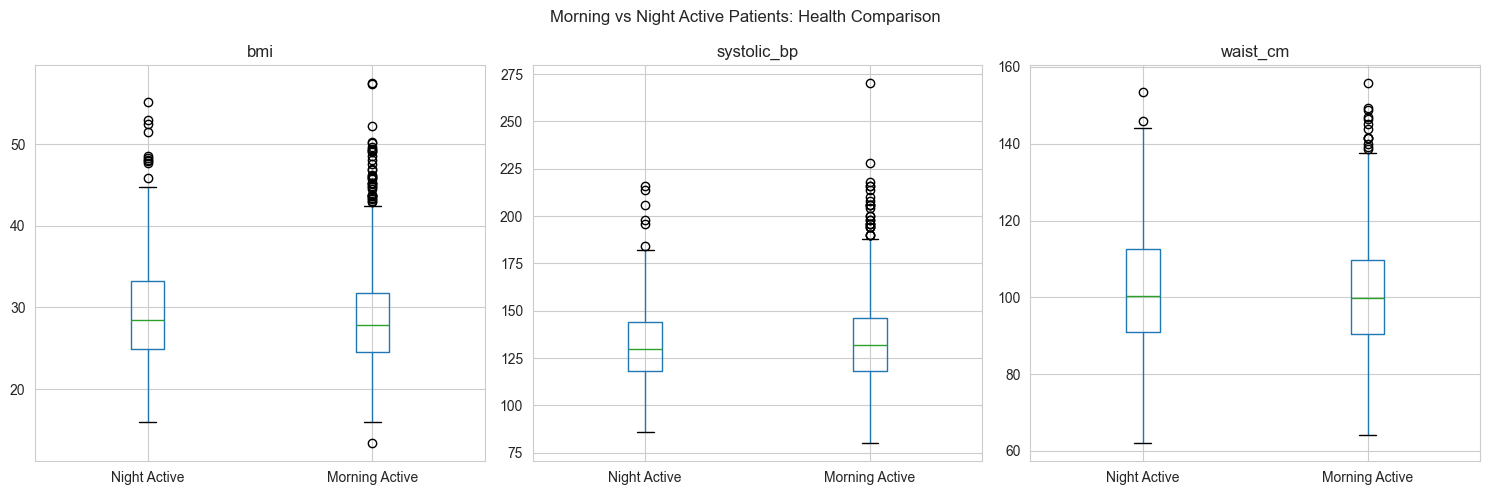

Hospitalization rate  —  Night Active: 17.9%   Morning Active: 14.6%


In [41]:
# Daily activity rhythm and morning vs night comparison
hourly      = master.groupby(['hour', 'hospitalized'])[['intensity', 'steps']].mean().reset_index()
hosp_labels = {0: 'Not Hospitalized', 1: 'Hospitalized'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for h_val, grp in hourly.groupby('hospitalized'):
    axes[0].plot(grp['hour'], grp['intensity'], marker='o', markersize=3, label=hosp_labels[h_val])
axes[0].set_title('Mean Intensity by Hour of Day')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Mean Intensity')
axes[0].legend()

for h_val, grp in hourly.groupby('hospitalized'):
    axes[1].plot(grp['hour'], grp['steps'], marker='o', markersize=3, label=hosp_labels[h_val])
axes[1].set_title('Mean Steps by Hour of Day')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('Mean Steps')
axes[1].legend()

plt.suptitle('Daily Activity Rhythm: Hospitalized vs Not', fontsize=13)
plt.tight_layout()
plt.show()

# Morning vs night dominant patients
morning_int = master[master['hour'].between(6, 11)].groupby('participant_id')['intensity'].mean().rename('int_morning')
night_int   = master[master['hour'].between(18, 23)].groupby('participant_id')['intensity'].mean().rename('int_night')
time_df     = pd.concat([morning_int, night_int], axis=1).dropna()
time_df     = time_df.join(
    agg.set_index('participant_id')[['bmi', 'systolic_bp', 'waist_cm', 'hospitalized']], how='inner'
).dropna()
time_df['morning_dominant'] = (time_df['int_morning'] > time_df['int_night']).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(['bmi', 'systolic_bp', 'waist_cm']):
    time_df.boxplot(column=col, by='morning_dominant', ax=axes[i])
    axes[i].set_xticklabels(['Night Active', 'Morning Active'])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Morning vs Night Active Patients: Health Comparison')
plt.tight_layout()
plt.show()

hosp_time = time_df.groupby('morning_dominant')['hospitalized'].mean().mul(100).round(1)
print('Hospitalization rate  —  Night Active: ' + str(hosp_time.get(0, 'N/A')) + '%   Morning Active: ' + str(hosp_time.get(1, 'N/A')) + '%')


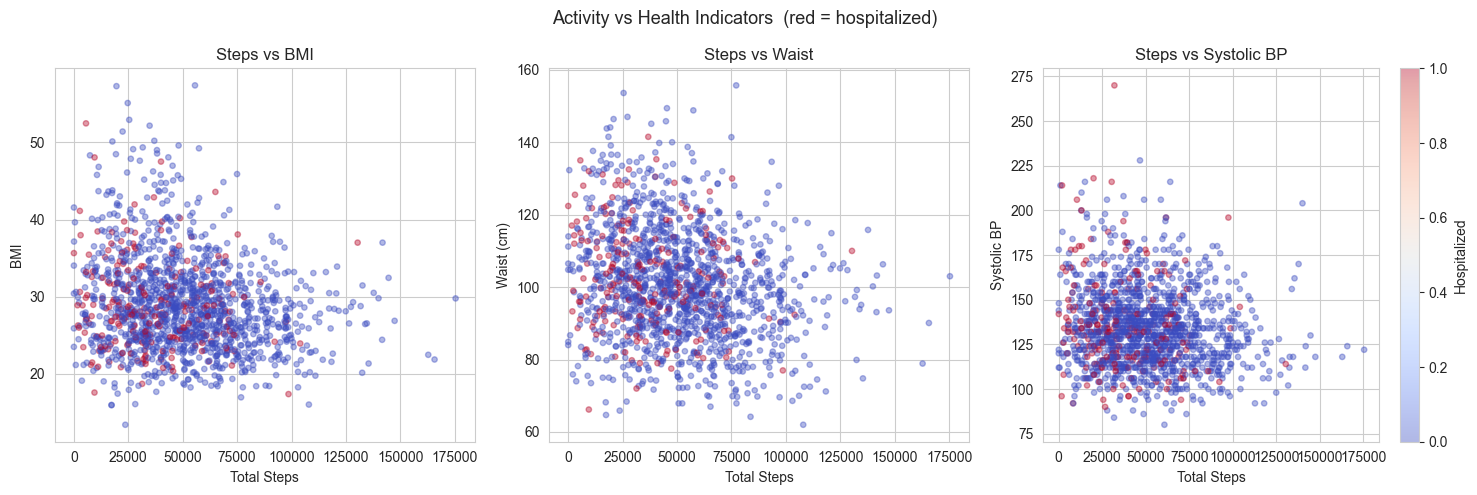

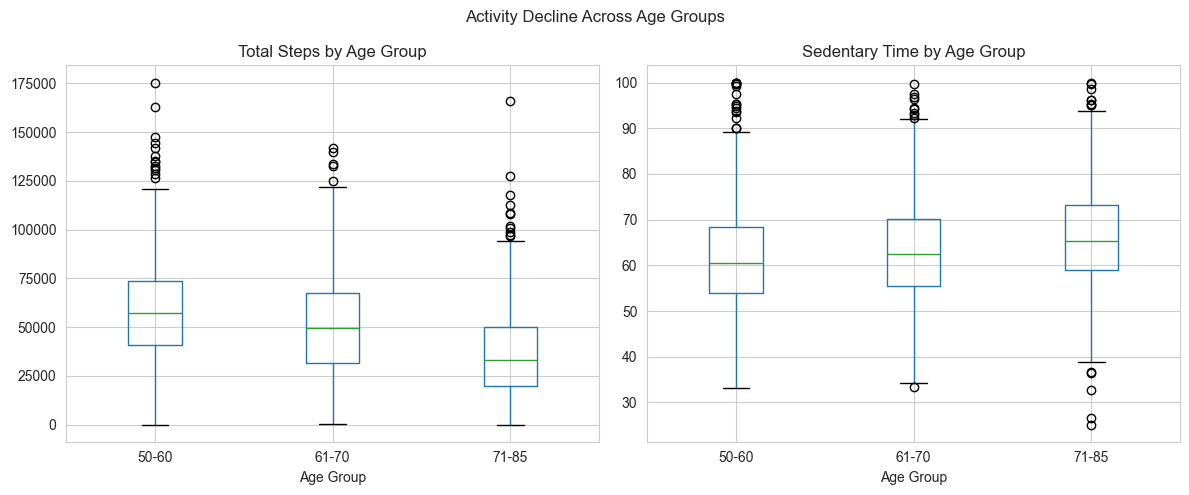

Hospitalization rate (%) by age group:
age_group
50-60     9.5
61-70    14.3
71-85    23.6


In [42]:
# Activity vs health indicators and age group comparisons
agg_clean  = agg.dropna(subset=['total_steps', 'bmi', 'waist_cm', 'systolic_bp']).copy()
scatter_kw = dict(alpha=0.4, c=agg_clean['hospitalized'], cmap='coolwarm', s=15)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(agg_clean['total_steps'], agg_clean['bmi'], **scatter_kw)
axes[0].set_xlabel('Total Steps'); axes[0].set_ylabel('BMI'); axes[0].set_title('Steps vs BMI')
axes[1].scatter(agg_clean['total_steps'], agg_clean['waist_cm'], **scatter_kw)
axes[1].set_xlabel('Total Steps'); axes[1].set_ylabel('Waist (cm)'); axes[1].set_title('Steps vs Waist')
sc = axes[2].scatter(agg_clean['total_steps'], agg_clean['systolic_bp'], **scatter_kw)
axes[2].set_xlabel('Total Steps'); axes[2].set_ylabel('Systolic BP'); axes[2].set_title('Steps vs Systolic BP')
plt.colorbar(sc, ax=axes[2], label='Hospitalized')
plt.suptitle('Activity vs Health Indicators  (red = hospitalized)', fontsize=13)
plt.tight_layout()
plt.show()

agg_age = agg.dropna(subset=['age', 'total_steps', 'pct_zero']).copy()
agg_age['age_group'] = pd.cut(agg_age['age'], bins=[49, 60, 70, 86], labels=['50-60', '61-70', '71-85'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
agg_age.boxplot(column='total_steps', by='age_group', ax=axes[0])
axes[0].set_title('Total Steps by Age Group'); axes[0].set_xlabel('Age Group')
agg_age.boxplot(column='pct_zero', by='age_group', ax=axes[1])
axes[1].set_title('Sedentary Time by Age Group'); axes[1].set_xlabel('Age Group')
plt.suptitle('Activity Decline Across Age Groups')
plt.tight_layout()
plt.show()

print('Hospitalization rate (%) by age group:')
print(agg_age.groupby('age_group')['hospitalized'].mean().mul(100).round(1).to_string())


## Part 2 — Trajectory Feature Engineering

From the raw minute-level data we derive three trajectory features, then define two
clinical grouping variables used throughout Parts 3–6.

**Trajectory features:**
- Sleep proxy — fraction of nighttime minutes (10pm to 6am) with zero intensity
- Activity slope — linear trend in daily step counts across the 7-day wear period.
  Negative = step count declining over the week.

**Clinical groupings:**
- Metabolic risk score — counts how many of three criteria a patient meets:
  BMI >= 30, systolic BP >= 140, waist >= sex-specific cutoff (102cm male / 88cm female).
  A score of 2 or more flags the patient as high metabolic risk.
- Activity group — Low / Medium / High by step count tercile.


In [43]:
check_group_quality(master, ['participant_id', 'day', 'hour', 'intensity', 'steps'], 'master')
check_group_quality(agg, ['bmi', 'systolic_bp', 'waist_cm', 'sex', 'total_steps', 'pct_zero'], 'agg')

# Sleep proxy
night_mask  = (master['hour'] >= 22) | (master['hour'] < 6)
night_df    = master.loc[night_mask, ['participant_id', 'intensity']].copy()
night_df['is_zero'] = (night_df['intensity'] == 0).astype(int)
sleep_proxy = night_df.groupby('participant_id')['is_zero'].mean().rename('sleep_proxy')

# Activity slope — linear trend in daily step totals
daily_steps = (master.groupby(['participant_id', 'day'])['steps']
               .sum().reset_index().rename(columns={'steps': 'daily_steps'}))

slope_results = {}
for pid, grp in daily_steps.groupby('participant_id'):
    x = grp['day'].values.astype(float)
    y = grp['daily_steps'].values.astype(float)
    if len(x) >= 2:
        x_c   = x - x.mean()
        denom = np.dot(x_c, x_c)
        slope_results[pid] = float(np.dot(x_c, y) / denom) if denom != 0 else 0.0
    else:
        slope_results[pid] = np.nan
activity_slope = pd.Series(slope_results, name='activity_slope')

# Join all features
features = (agg.set_index('participant_id')
              .join([sleep_proxy, activity_slope], how='left')
              .reset_index())

# Metabolic risk score (based on ATP III criteria)
# NHANES sex coding: 1 = Male, 2 = Female
features['waist_cutoff'] = np.where(features['sex'] == 1, 102.0, 88.0)
features['risk_bmi']     = (features['bmi']         >= 30).astype(int)
features['risk_bp']      = (features['systolic_bp'] >= 140).astype(int)
features['risk_waist']   = (features['waist_cm']    >= features['waist_cutoff']).astype(int)
features['risk_score']   = features[['risk_bmi', 'risk_bp', 'risk_waist']].sum(axis=1)
features['high_risk']    = (features['risk_score']  >= 2).astype(int)

# Activity group by step count tercile
features_valid = features.dropna(subset=['total_steps'])
features.loc[features_valid.index, 'activity_group'] = pd.qcut(
    features_valid['total_steps'], q=3, labels=['Low', 'Medium', 'High']
)

check_group_quality(features, ['sleep_proxy', 'activity_slope', 'risk_score', 'high_risk'], 'new features')

print('Metabolic risk score distribution:')
print(features['risk_score'].value_counts().sort_index().to_string())
print()
print('High metabolic risk (score >= 2): ' + str(features['high_risk'].sum()) + ' patients  (' + str(round(features['high_risk'].mean() * 100, 1)) + '%)')
print()
print('Activity slope — mean: ' + str(round(features['activity_slope'].mean(), 1)) + '  (negative = declining over the wear week)')
print('Sleep proxy    — mean: ' + str(round(features['sleep_proxy'].mean(), 3)) + '  (fraction of night minutes at zero intensity)')


Data Quality Check — master
--------------------------------------------------
  participant_id          NaN=0 (0.0%)   Outliers=0  
  day                     NaN=0 (0.0%)   Outliers=0  (categorical — outlier check skipped)
  hour                    NaN=0 (0.0%)   Outliers=0  
  intensity               NaN=0 (0.0%)   Outliers=2508877   [outliers]
  steps                   NaN=0 (0.0%)   Outliers=2378446   [outliers]
Result: 2 column(s) flagged

Data Quality Check — agg
--------------------------------------------------
  bmi                     NaN=12 (0.79%)   Outliers=5   [NaN!!] [outliers]
  systolic_bp             NaN=0 (0.0%)   Outliers=1   [outliers]
  waist_cm                NaN=52 (3.4%)   Outliers=0   [NaN!!]
  sex                     NaN=0 (0.0%)   Outliers=0  (categorical — outlier check skipped)
  total_steps             NaN=0 (0.0%)   Outliers=0  
  pct_zero                NaN=0 (0.0%)   Outliers=0  
Result: 3 column(s) flagged

Data Quality Check — new features
----------

## Part 3 — Risk Stratification and Kaplan-Meier Survival

Patients are split into Low, Medium, and High activity groups by step count tercile.
Kaplan-Meier curves show the probability of remaining hospitalization-free as a
function of age, using (age - 50) as the observation window.

This is a cross-sectional approximation — we are not following patients over time.
The assumption is that a hospitalized patient at age 65 experienced that event at
year 15 of the observation period, and a non-hospitalized patient at age 70 is
censored at year 20. The curves reveal whether lower-activity patients in our
sample tended to be hospitalized at earlier ages.


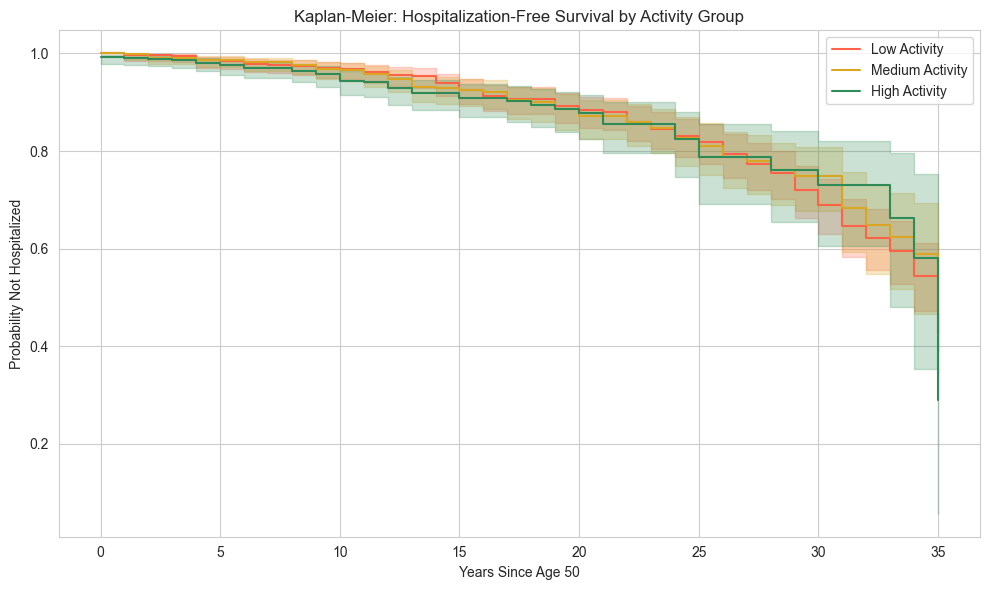

Group summary:
                  n  hosp_rate  mean_steps  mean_slope
activity_group                                        
Low             510      0.257   20495.686      33.284
Medium          509      0.128   46600.173      82.309
High            509      0.088   80500.743     189.543


In [44]:
km_df = features.dropna(subset=['total_steps', 'hospitalized', 'age', 'activity_group']).copy()
km_df['T'] = km_df['age'] - 50

kmf    = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))
colors  = {'Low': 'tomato', 'Medium': 'goldenrod', 'High': 'seagreen'}

for group in ['Low', 'Medium', 'High']:
    mask = km_df['activity_group'] == group
    kmf.fit(km_df.loc[mask, 'T'],
            event_observed=km_df.loc[mask, 'hospitalized'],
            label=group + ' Activity')
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[group])

ax.set_title('Kaplan-Meier: Hospitalization-Free Survival by Activity Group')
ax.set_xlabel('Years Since Age 50')
ax.set_ylabel('Probability Not Hospitalized')
ax.legend()
plt.tight_layout()
plt.show()

print('Group summary:')
summary = km_df.groupby('activity_group').agg(
    n=('participant_id', 'count'),
    hosp_rate=('hospitalized', 'mean'),
    mean_steps=('total_steps', 'mean'),
    mean_slope=('activity_slope', 'mean')
).round(3)
print(summary.to_string())


## Part 4 — Cox Proportional Hazards Model

We use (age - 50) as the observation duration and hospitalization as the event.
Age is not included as a covariate since it defines the time axis. Covariates
are the trajectory features from Part 2 plus BMI and sex as clinical controls.


Data Quality Check — Cox model inputs
--------------------------------------------------
  total_steps             NaN=0 (0.0%)   Outliers=0  
  pct_zero                NaN=0 (0.0%)   Outliers=0  
  sleep_proxy             NaN=0 (0.0%)   Outliers=30   [outliers]
  activity_slope          NaN=0 (0.0%)   Outliers=14   [outliers]
  bmi                     NaN=12 (0.79%)   Outliers=5   [NaN!!] [outliers]
  sex                     NaN=0 (0.0%)   Outliers=0  (categorical — outlier check skipped)
  hospitalized            NaN=0 (0.0%)   Outliers=0  (categorical — outlier check skipped)
  age                     NaN=0 (0.0%)   Outliers=0  
Result: 3 column(s) flagged



<lifelines.CoxPHFitter: fitted with 1516 total observations, 1278 right-censored observations>
             duration col = 'duration'
                event col = 'hospitalized'
      baseline estimation = breslow
   number of observations = 1516
number of events observed = 238
   partial log-likelihood = -1429.412
         time fit was run = 2026-04-30 07:16:45 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
total_steps     0.000     1.000     0.000           0.000           0.000               1.000               1.000
pct_zero        0.025     1.025     0.008           0.009           0.042               1.009               1.043
sleep_proxy    -2.265     0.104     0.753          -3.742          -0.789               0.024               0.454
activity_slope -0.000     1.000     0.000          -0.000           0.000               1.000               1.000
bmi             0.058     1.059     0.011           0.037           0.078               1.037               1.082
sex            -0.056     0.945     0.137          -0.324           0.212               0.723               1.236

                cmp to      z       p  -log2(p)
covariate                                      
total_steps      0.000  2.113   0.035     4.854
pct_zero         0.000  2.980   0.003     8.438
sleep_proxy      0.000 -3.008   0.003     8.569
activity_slope   0.000 -0.668   0.504     0.988
bmi              0.000  5.415 <0.0005    23.961
sex              0.000 -0.410   0.682     0.553
---
Concordance = 0.639
Partial AIC = 2870.823
log-likelihood ratio test = 38.923 on 6 df
-log2(p) of ll-ratio test = 20.364


Concordance Index (C-index): 0.6393
  0.5 = random chance    0.65+ = clinically useful    1.0 = perfect


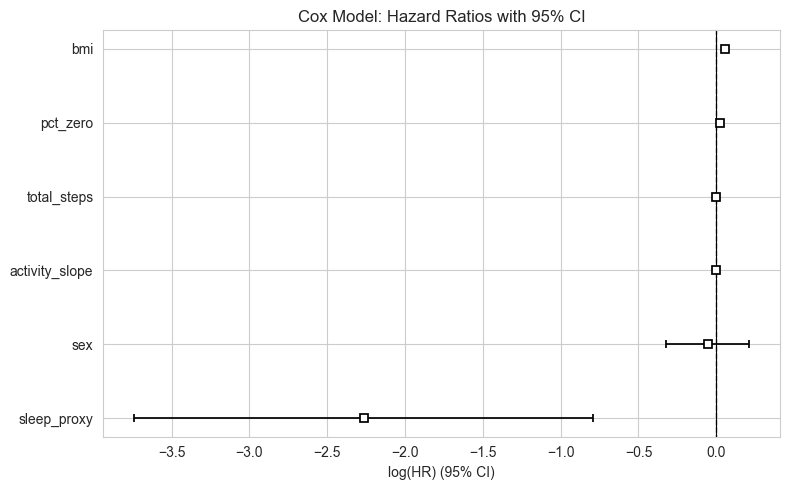

In [45]:
cox_features = ['total_steps', 'pct_zero', 'sleep_proxy', 'activity_slope', 'bmi', 'sex']
check_group_quality(features, cox_features + ['hospitalized', 'age'], 'Cox model inputs')

cox_df             = features.dropna(subset=cox_features + ['hospitalized', 'age']).copy()
cox_df['duration'] = cox_df['age'] - 50

cph = CoxPHFitter()
cph.fit(cox_df[cox_features + ['duration', 'hospitalized']],
        duration_col='duration', event_col='hospitalized')

cph.print_summary(decimals=3)
print()
print('Concordance Index (C-index): ' + str(round(cph.concordance_index_, 4)))
print('  0.5 = random chance    0.65+ = clinically useful    1.0 = perfect')

fig, ax = plt.subplots(figsize=(8, 5))
cph.plot(ax=ax)
ax.set_title('Cox Model: Hazard Ratios with 95% CI')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


### Reading the Cox Output

**The table** shows how each variable relates to hospitalization hazard.

**exp(coef) is the hazard ratio** — the multiplier on hospitalization risk for a
one-unit increase in that variable, holding everything else constant.

- exp(coef) below 1.0: that variable is associated with lower hospitalization risk
- exp(coef) above 1.0: associated with higher risk
- The p-value and 95% CI tell you whether the effect is statistically reliable

**How to read each covariate:**

- **total_steps**: the coefficient looks tiny (-0.000) because a single step is a tiny unit.
  The direction matters — negative means more steps reduces hazard.
  Scale it mentally: 10,000 more steps per week moves the coefficient by 10,000x.

- **pct_zero**: fraction of minutes with zero intensity. A positive coefficient means
  more sedentary time is associated with higher hospitalization hazard.

- **sleep_proxy**: fraction of nighttime minutes at zero intensity.
  Interpret carefully — high values could mean good sleep or nighttime immobility.

- **activity_slope**: linear trend in daily steps over the wear week.
  A negative coefficient here means declining step count increases hospitalization hazard.
  This is the trajectory signal the project is built around.

- **bmi**: positive coefficient means higher BMI is associated with higher hazard, as expected.

- **sex**: NHANES codes 1 = Male, 2 = Female. A negative coefficient means
  females in this sample had lower hospitalization hazard than males at the same activity level.

**The C-index** answers: out of every pair of patients where one was hospitalized
and one was not, what fraction did the model rank correctly?
A C-index of 0.70 means it got 70% of those comparisons right.
0.50 would be no better than random.

**The hazard ratio plot** shows each covariate's exp(coef) with its 95% confidence interval.
Variables whose confidence interval does not cross 1.0 (the vertical line at 0 on the log scale)
are statistically significant.


## Part 5 — Clinical Translation

What weekly step count best separates high-risk from low-risk patients?
An ROC curve shows the full sensitivity/specificity tradeoff across all thresholds.
We find the optimal cut using Youden's J statistic, then report hospitalization rates
at a set of clinically round step values so the result is actionable.


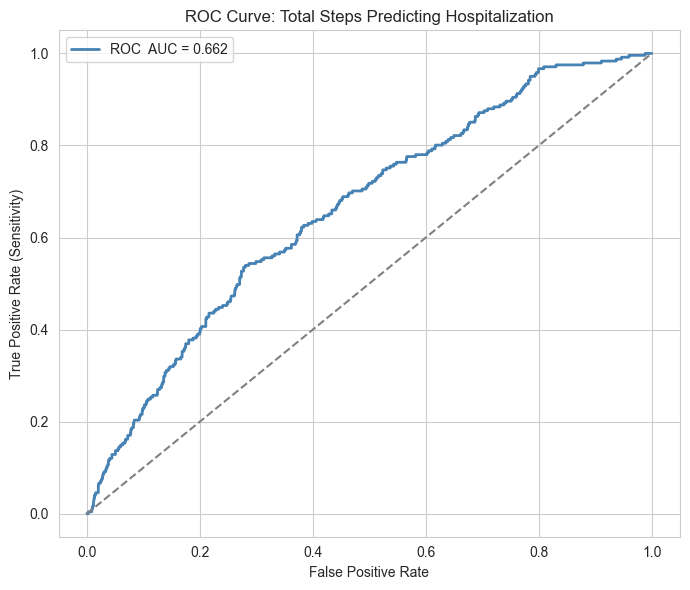

Optimal threshold (Youden J): 33404 steps/week
  Sensitivity: 0.539
  Specificity: 0.72

Above threshold (lower risk):  10.8% hospitalized  (n=1038)
Below threshold (higher risk): 26.3% hospitalized  (n=490)

Hospitalization rate at round-number thresholds:
  Threshold    Below (higher risk)    Above (lower risk)
  15000        30.2                   14.2
  25000        28.1                   12.6
  35000        25.2                   10.8
  45000        21.9                   10.1
  55000        20.0                   9.0
  65000        18.8                   7.4


In [46]:
ct_df = features.dropna(subset=['total_steps', 'hospitalized'])
fpr, tpr, thresholds = roc_curve(ct_df['hospitalized'], -ct_df['total_steps'])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2, label='ROC  AUC = ' + str(round(roc_auc, 3)))
ax.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve: Total Steps Predicting Hospitalization')
ax.legend()
plt.tight_layout()
plt.show()

youdens_j   = tpr - fpr
best_idx    = int(np.argmax(youdens_j))
best_thresh = int(-thresholds[best_idx])

print('Optimal threshold (Youden J): ' + str(best_thresh) + ' steps/week')
print('  Sensitivity: ' + str(round(tpr[best_idx], 3)))
print('  Specificity: ' + str(round(1 - fpr[best_idx], 3)))
print()

above = ct_df[ct_df['total_steps'] >= best_thresh]
below = ct_df[ct_df['total_steps'] <  best_thresh]
print('Above threshold (lower risk):  ' + str(round(above['hospitalized'].mean() * 100, 1)) + '% hospitalized  (n=' + str(len(above)) + ')')
print('Below threshold (higher risk): ' + str(round(below['hospitalized'].mean() * 100, 1)) + '% hospitalized  (n=' + str(len(below)) + ')')
print()
print('Hospitalization rate at round-number thresholds:')
print('  Threshold    Below (higher risk)    Above (lower risk)')
for cut in [15000, 25000, 35000, 45000, 55000, 65000]:
    lo = ct_df[ct_df['total_steps'] < cut]['hospitalized'].mean()
    hi = ct_df[ct_df['total_steps'] >= cut]['hospitalized'].mean()
    print('  ' + str(cut).ljust(13) + str(round(lo * 100, 1)).ljust(23) + str(round(hi * 100, 1)))


## Part 6 — Activity Trajectory Prediction

Each patient has up to 7 days of wear data, which gives us a short time series of
daily step counts. We use this in two ways:

First, we visualize the 7-day trajectory shape by activity group and by metabolic risk
group. This shows whether declining activity over the week differs between groups.

Second, we build a simple autoregressive model (AR(1)) that predicts a patient's
step count on day N+1 from their count on day N. This is the most basic time series
model — yesterday predicts today. The R-squared and MAE tell us how much of
next-day activity is explained by prior-day activity, and the scatter plot shows
where the model works and where it breaks down.

This sets up a future extension: use the hourly intensity pattern from earlier in the
day to predict later-in-day activity, which is the foundation for a real-time
wearable risk dashboard.


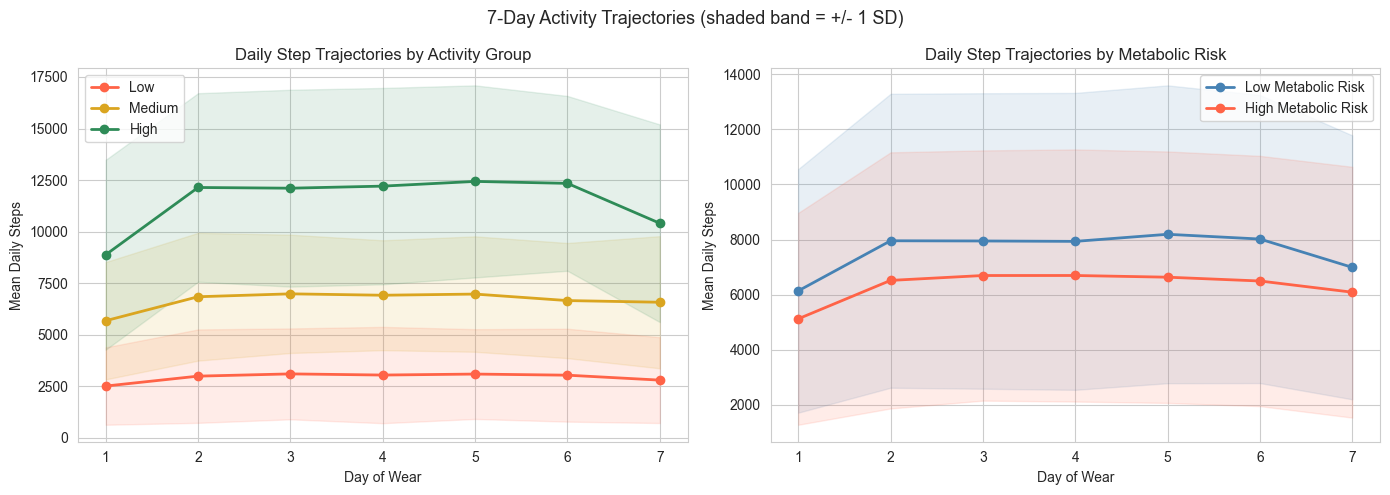

AR(1) Model — Predicting Next-Day Step Count from Prior Day
Cross-validated R2:  0.424 +/- 0.025
Cross-validated MAE: 2752 steps
Lag-1 coefficient:   0.6578
  A coefficient near 1.0 means yesterday strongly predicts today.
  A lower value means daily activity is more variable.



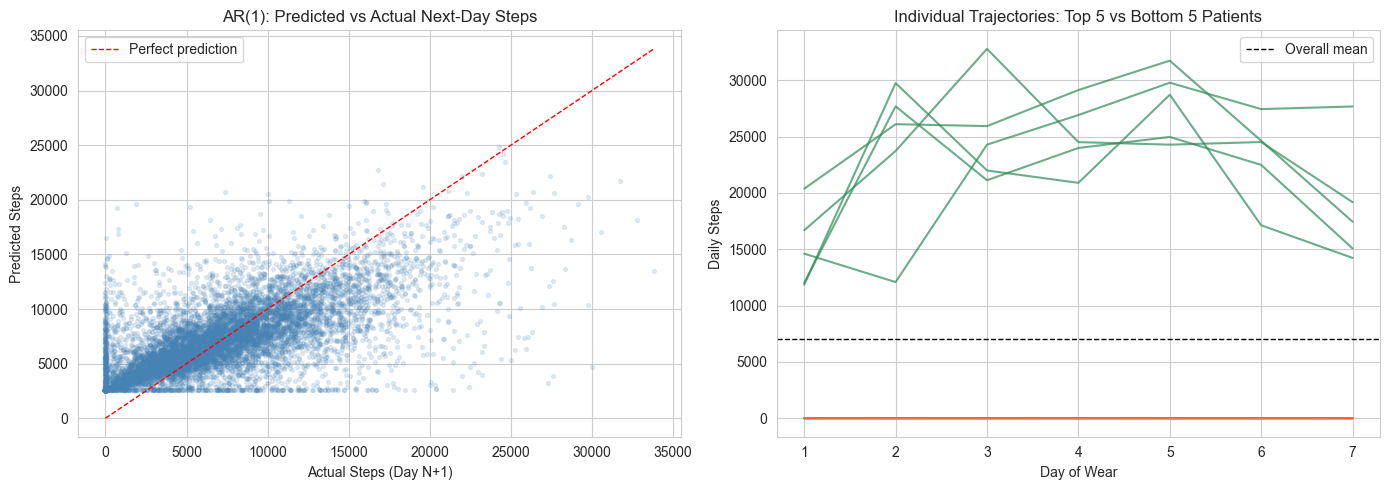

In [47]:
# Daily step totals per patient
daily = (master.groupby(['participant_id', 'day'])['steps']
         .sum().reset_index().rename(columns={'steps': 'daily_steps'}))
daily = daily.merge(
    features[['participant_id', 'activity_group', 'high_risk']].dropna(subset=['activity_group']),
    on='participant_id', how='left'
)

# 7-day trajectory by group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grp_colors = {'Low': 'tomato', 'Medium': 'goldenrod', 'High': 'seagreen'}
for group, gdf in daily.dropna(subset=['activity_group']).groupby('activity_group'):
    s = gdf.groupby('day')['daily_steps'].agg(['mean', 'std'])
    axes[0].plot(s.index, s['mean'], marker='o', lw=2, label=group, color=grp_colors[group])
    axes[0].fill_between(s.index, s['mean'] - s['std'], s['mean'] + s['std'],
                         alpha=0.12, color=grp_colors[group])
axes[0].set_title('Daily Step Trajectories by Activity Group')
axes[0].set_xlabel('Day of Wear'); axes[0].set_ylabel('Mean Daily Steps')
axes[0].legend()

risk_colors  = {0: 'steelblue', 1: 'tomato'}
risk_labels  = {0: 'Low Metabolic Risk', 1: 'High Metabolic Risk'}
for rv, gdf in daily.dropna(subset=['high_risk']).groupby('high_risk'):
    s = gdf.groupby('day')['daily_steps'].agg(['mean', 'std'])
    axes[1].plot(s.index, s['mean'], marker='o', lw=2, label=risk_labels[rv], color=risk_colors[rv])
    axes[1].fill_between(s.index, s['mean'] - s['std'], s['mean'] + s['std'],
                         alpha=0.12, color=risk_colors[rv])
axes[1].set_title('Daily Step Trajectories by Metabolic Risk')
axes[1].set_xlabel('Day of Wear'); axes[1].set_ylabel('Mean Daily Steps')
axes[1].legend()

plt.suptitle('7-Day Activity Trajectories (shaded band = +/- 1 SD)', fontsize=13)
plt.tight_layout()
plt.show()

# AR(1): yesterday steps -> today steps
lag = daily.sort_values(['participant_id', 'day']).copy()
lag['steps_lag1'] = lag.groupby('participant_id')['daily_steps'].shift(1)
lag = lag.dropna(subset=['steps_lag1'])

X_ts = lag[['steps_lag1']].values
y_ts = lag['daily_steps'].values

lr_ts = LinearRegression()
cv_r2 = cross_val_score(lr_ts, X_ts, y_ts, cv=5, scoring='r2')
cv_mae = -cross_val_score(lr_ts, X_ts, y_ts, cv=5, scoring='neg_mean_absolute_error')
lr_ts.fit(X_ts, y_ts)
y_pred_ts = lr_ts.predict(X_ts)

print('AR(1) Model — Predicting Next-Day Step Count from Prior Day')
print('Cross-validated R2:  ' + str(round(cv_r2.mean(), 3)) + ' +/- ' + str(round(cv_r2.std(), 3)))
print('Cross-validated MAE: ' + str(int(round(cv_mae.mean(), 0))) + ' steps')
print('Lag-1 coefficient:   ' + str(round(lr_ts.coef_[0], 4)))
print('  A coefficient near 1.0 means yesterday strongly predicts today.')
print('  A lower value means daily activity is more variable.')
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_ts, y_pred_ts, alpha=0.15, s=8, color='steelblue')
axes[0].plot([0, y_ts.max()], [0, y_ts.max()], 'r--', lw=1, label='Perfect prediction')
axes[0].set_xlabel('Actual Steps (Day N+1)')
axes[0].set_ylabel('Predicted Steps')
axes[0].set_title('AR(1): Predicted vs Actual Next-Day Steps')
axes[0].legend()

# Sample trajectories — 5 most active and 5 least active patients
pid_means = daily.groupby('participant_id')['daily_steps'].mean()
sample_pids = pid_means.nlargest(5).index.tolist() + pid_means.nsmallest(5).index.tolist()
overall_mean = daily['daily_steps'].mean()
for pid in sample_pids:
    pdata = daily[daily['participant_id'] == pid].sort_values('day')
    color = 'seagreen' if pdata['daily_steps'].mean() > overall_mean else 'tomato'
    axes[1].plot(pdata['day'], pdata['daily_steps'], alpha=0.7, color=color, lw=1.5)
axes[1].axhline(overall_mean, color='black', linestyle='--', lw=1, label='Overall mean')
axes[1].set_xlabel('Day of Wear')
axes[1].set_ylabel('Daily Steps')
axes[1].set_title('Individual Trajectories: Top 5 vs Bottom 5 Patients')
axes[1].legend()

plt.tight_layout()
plt.show()


## Part 7 — Cardiovascular Health Clusters

Note: the NHANES dataset does not include resting heart rate. The closest available
proxies are systolic BP, diastolic BP, BMI, and waist circumference — the four
standard indicators used in metabolic syndrome criteria.

We use K-means clustering on those four variables to find natural health groups in
the data. The elbow plot below shows inertia across values of K so we can pick the
number of clusters where adding another group stops buying much separation. We then
profile each cluster by its mean health indicators and show average weekly steps
and hospitalization rate per group.


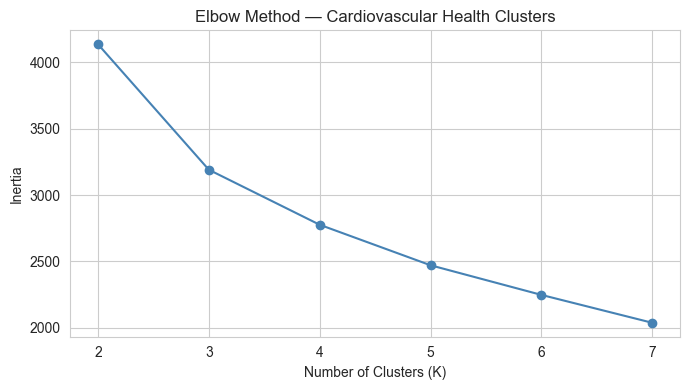

Cluster profiles (sorted by mean systolic BP):
                systolic_bp  diastolic_bp    bmi  waist_cm  total_steps  hospitalized
health_cluster                                                                       
3                    123.58         67.59  29.91    105.28     50450.20          0.16
2                    124.03         64.28  23.38     86.53     54262.81          0.15
0                    136.28         73.53  39.05    124.04     39688.41          0.16
1                    159.72         82.90  27.34     97.09     50953.97          0.14

Cluster 3: overweight BMI, normal BP, high waist  —  avg steps: 50450  hosp rate: 16.0%
Cluster 2: healthy BMI, normal BP  —  avg steps: 54262  hosp rate: 15.0%
Cluster 0: obese BMI, normal BP, high waist  —  avg steps: 39688  hosp rate: 16.0%
Cluster 1: overweight BMI, hypertensive  —  avg steps: 50953  hosp rate: 14.0%


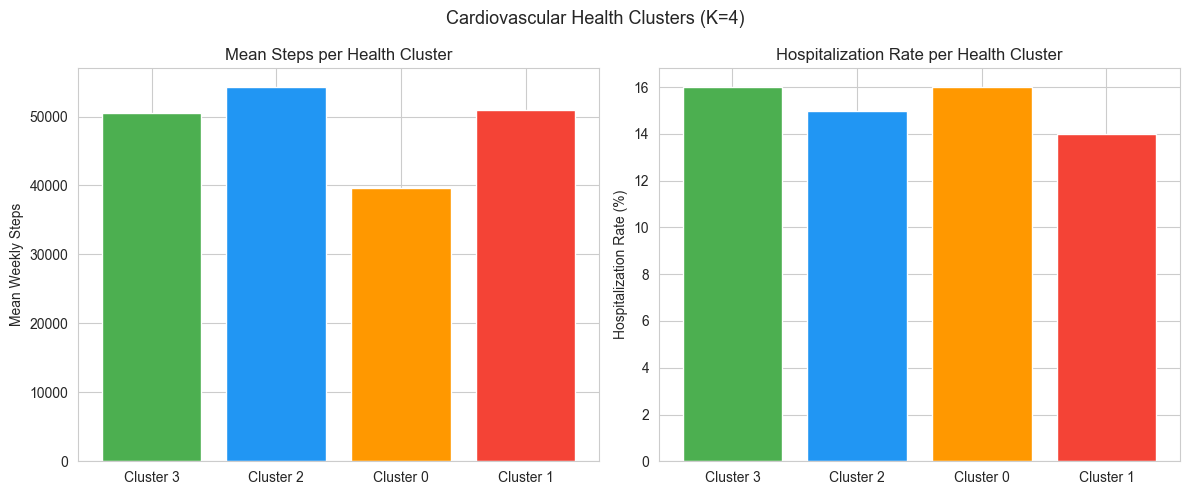

In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

clust_cols = ['systolic_bp', 'diastolic_bp', 'bmi', 'waist_cm']
clust_df   = features.dropna(subset=clust_cols).copy()
X_clust    = StandardScaler().fit_transform(clust_df[clust_cols])

# Elbow method
inertias = []
K_range  = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias.append(km.fit(X_clust).inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertias, marker='o', color='steelblue')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Cardiovascular Health Clusters')
plt.tight_layout()
plt.show()

K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
clust_df['health_cluster'] = km_final.fit_predict(X_clust)

profile = clust_df.groupby('health_cluster')[clust_cols + ['total_steps', 'hospitalized']].mean().round(2)
print('Cluster profiles (sorted by mean systolic BP):')
print(profile.sort_values('systolic_bp').to_string())
print()

# Label each cluster with a short description
for cid, row in profile.sort_values('systolic_bp').iterrows():
    tags = []
    if row['bmi'] >= 30:
        tags.append('obese BMI')
    elif row['bmi'] < 25:
        tags.append('healthy BMI')
    else:
        tags.append('overweight BMI')
    if row['systolic_bp'] >= 140:
        tags.append('hypertensive')
    else:
        tags.append('normal BP')
    if row['waist_cm'] >= 100:
        tags.append('high waist')
    print('Cluster ' + str(cid) + ': ' + ', '.join(tags) + '  —  avg steps: ' + str(int(row['total_steps'])) + '  hosp rate: ' + str(round(row['hospitalized'] * 100, 1)) + '%')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette   = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']

cluster_order  = profile.sort_values('systolic_bp').index.tolist()
step_vals      = [profile.loc[c, 'total_steps'] for c in cluster_order]
hosp_vals      = [profile.loc[c, 'hospitalized'] * 100 for c in cluster_order]
cluster_labels = ['Cluster ' + str(c) for c in cluster_order]

axes[0].bar(cluster_labels, step_vals, color=palette[:K])
axes[0].set_ylabel('Mean Weekly Steps')
axes[0].set_title('Mean Steps per Health Cluster')

axes[1].bar(cluster_labels, hosp_vals, color=palette[:K])
axes[1].set_ylabel('Hospitalization Rate (%)')
axes[1].set_title('Hospitalization Rate per Health Cluster')

plt.suptitle('Cardiovascular Health Clusters (K=' + str(K) + ')', fontsize=13)
plt.tight_layout()
plt.show()


## Part 8 — Activity Timing and Health Outcomes

Total step count tells you how much someone moves. The question here is whether
the *when* of that movement matters independently of the *how much*.

The first cell compares morning-dominant vs night-dominant patients on health outcomes,
including an important control: among patients whose total activity is within one standard
deviation of the mean (i.e., typical movers), does timing still predict health? If yes,
that is a timing effect independent of volume.

The second cell characterizes each patient by four pattern features — peak activity hour,
hourly spread (concentrated vs distributed), weekly consistency, and morning fraction —
and clusters them into activity archetypes. Each archetype gets a visual fingerprint
showing its average hourly step curve, alongside hospitalization and metabolic risk rates.


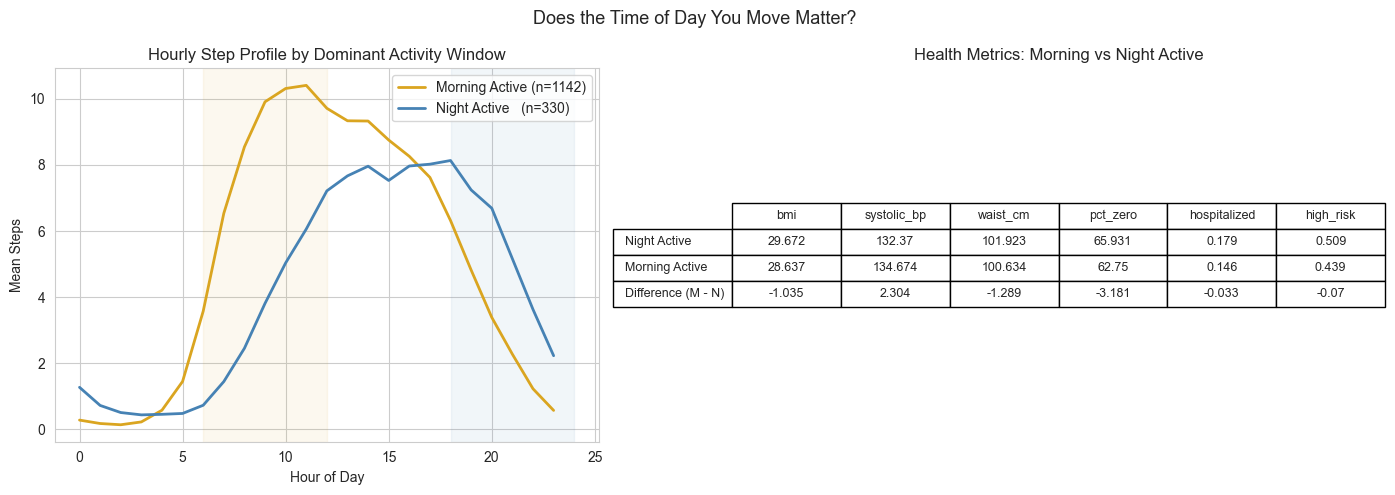

Among patients with typical activity levels (within 1 SD of mean steps, n=1010):
                     Hospitalized    High Metabolic Risk    Mean BMI
  Night Active:      15.1%             49.1%                29.46
  Morning Active:    14.9%             46.1%                28.88

If the differences persist after controlling for total volume,
it suggests *when* you move matters, not just how much.


In [49]:
# Morning vs night: hourly fingerprint and health comparison
morning_int = master[master['hour'].between(6, 11)].groupby('participant_id')['intensity'].mean().rename('int_morning')
night_int   = master[master['hour'].between(18, 23)].groupby('participant_id')['intensity'].mean().rename('int_night')
timing_df   = pd.concat([morning_int, night_int], axis=1).dropna()
timing_df   = timing_df.join(
    features.set_index('participant_id')[['bmi', 'systolic_bp', 'waist_cm', 'hospitalized', 'high_risk', 'total_steps', 'pct_zero']],
    how='inner'
).dropna()
timing_df['morning_dominant'] = (timing_df['int_morning'] > timing_df['int_night']).astype(int)

morning_pids = timing_df[timing_df['morning_dominant'] == 1].index
night_pids   = timing_df[timing_df['morning_dominant'] == 0].index

morning_curve = master[master['participant_id'].isin(morning_pids)].groupby('hour')['steps'].mean()
night_curve   = master[master['participant_id'].isin(night_pids)].groupby('hour')['steps'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(morning_curve.index, morning_curve.values, color='goldenrod', lw=2, label='Morning Active (n=' + str(len(morning_pids)) + ')')
axes[0].plot(night_curve.index,   night_curve.values,   color='steelblue',  lw=2, label='Night Active   (n=' + str(len(night_pids)) + ')')
axes[0].axvspan(6,  12, alpha=0.07, color='goldenrod')
axes[0].axvspan(18, 24, alpha=0.07, color='steelblue')
axes[0].set_title('Hourly Step Profile by Dominant Activity Window')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Steps')
axes[0].legend()

health_cols  = ['bmi', 'systolic_bp', 'waist_cm', 'pct_zero', 'hospitalized', 'high_risk']
compare      = timing_df.groupby('morning_dominant')[health_cols].mean().round(3)
compare.index = ['Night Active', 'Morning Active']
diff          = compare.loc['Morning Active'] - compare.loc['Night Active']
compare.loc['Difference (M - N)'] = diff.round(3)

axes[1].axis('off')
tbl = axes[1].table(
    cellText=compare.round(3).values,
    rowLabels=compare.index.tolist(),
    colLabels=health_cols,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)
axes[1].set_title('Health Metrics: Morning vs Night Active')

plt.suptitle('Does the Time of Day You Move Matter?', fontsize=13)
plt.tight_layout()
plt.show()

# Control for activity volume: within 1 SD of mean steps
mean_s = timing_df['total_steps'].mean()
std_s  = timing_df['total_steps'].std()
normal = timing_df[timing_df['total_steps'].between(mean_s - std_s, mean_s + std_s)]
n_norm = normal.groupby('morning_dominant')

hosp_norm = n_norm['hospitalized'].mean().mul(100).round(1)
risk_norm = n_norm['high_risk'].mean().mul(100).round(1)
bmi_norm  = n_norm['bmi'].mean().round(2)

print('Among patients with typical activity levels (within 1 SD of mean steps, n=' + str(len(normal)) + '):')
print('                     Hospitalized    High Metabolic Risk    Mean BMI')
print('  Night Active:      ' + str(hosp_norm.get(0, '-')) + '%             ' + str(risk_norm.get(0, '-')) + '%                ' + str(bmi_norm.get(0, '-')))
print('  Morning Active:    ' + str(hosp_norm.get(1, '-')) + '%             ' + str(risk_norm.get(1, '-')) + '%                ' + str(bmi_norm.get(1, '-')))
print()
print('If the differences persist after controlling for total volume,')
print('it suggests *when* you move matters, not just how much.')


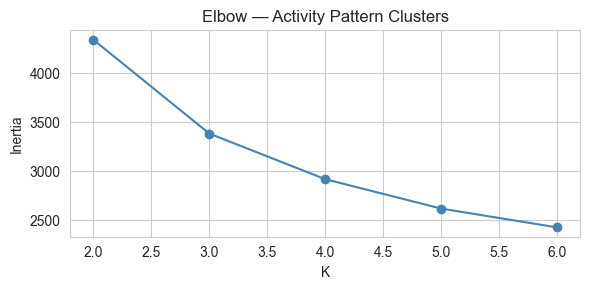

Activity pattern cluster profiles:
                 peak_hour  hourly_spread  daily_spread  morning_frac  total_steps  hospitalized  high_risk
pattern_cluster                                                                                            
0                    9.824          3.560      1823.064         0.416    38331.415         0.185      0.479
1                   15.465          6.473      3975.582         0.279    69131.275         0.085      0.366
2                    9.421          7.785      4507.625         0.457    79957.179         0.082      0.339
3                   15.139          2.820      1596.773         0.244    30394.465         0.218      0.508

Cluster 0 (morning-heavy, spread through day, consistent week)  hosp=18.5%  metab_risk=47.9%  steps=38331
Cluster 1 (non-morning, concentrated bursts, variable week)  hosp=8.5%  metab_risk=36.6%  steps=69131
Cluster 2 (morning-heavy, concentrated bursts, variable week)  hosp=8.2%  metab_risk=33.9%  steps=79957
Clus

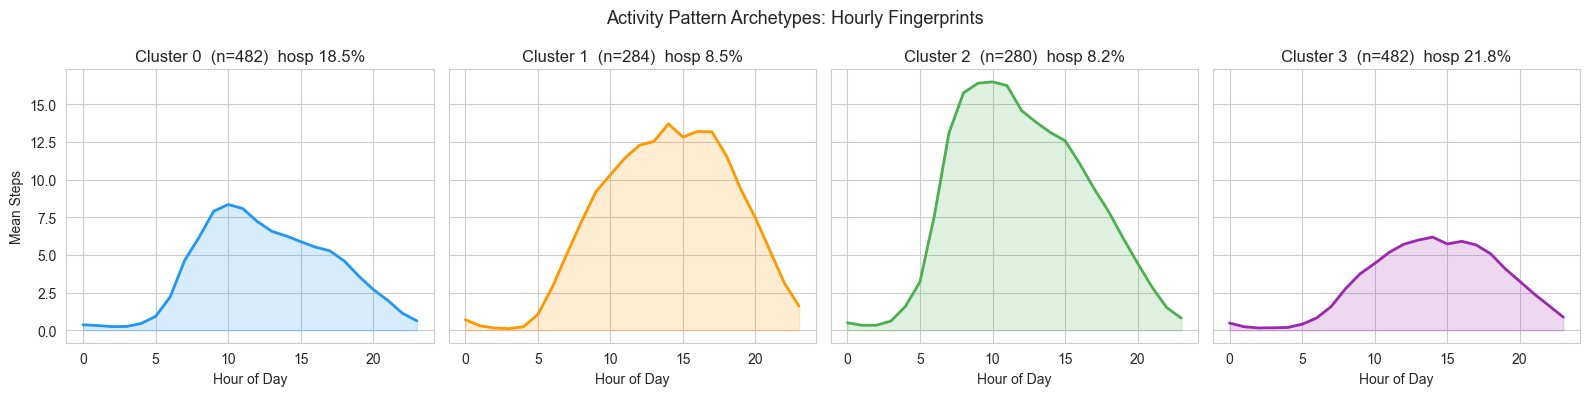

In [50]:
# Activity pattern archetypes: peak hour, spread, consistency, morning fraction
peak_by_hour  = master.groupby(['participant_id', 'hour'])['steps'].mean().reset_index()
peak_rows     = peak_by_hour.loc[peak_by_hour.groupby('participant_id')['steps'].idxmax()]
peak_hour_map = peak_rows.set_index('participant_id')['hour'].rename('peak_hour')

hourly_spread = (master.groupby(['participant_id', 'hour'])['steps'].mean()
                 .groupby('participant_id').std().rename('hourly_spread'))

daily_spread  = (master.groupby(['participant_id', 'day'])['steps'].sum()
                 .groupby('participant_id').std().rename('daily_spread'))

total_per_p   = master.groupby('participant_id')['steps'].sum()
morning_steps = master[master['hour'].between(6, 11)].groupby('participant_id')['steps'].sum()
morning_frac  = (morning_steps / total_per_p).rename('morning_frac')

pattern_df = pd.concat([peak_hour_map, hourly_spread, daily_spread, morning_frac], axis=1).dropna()
pattern_df = pattern_df.join(
    features.set_index('participant_id')[['hospitalized', 'high_risk', 'total_steps', 'pct_zero']],
    how='inner'
).dropna()

pat_cols = ['peak_hour', 'hourly_spread', 'daily_spread', 'morning_frac']
X_pat    = StandardScaler().fit_transform(pattern_df[pat_cols])

inertias_pat = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pat).inertia_ for k in range(2, 7)]
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(2, 7), inertias_pat, marker='o', color='steelblue')
ax.set_title('Elbow — Activity Pattern Clusters')
ax.set_xlabel('K'); ax.set_ylabel('Inertia')
plt.tight_layout()
plt.show()

K_pat = 4
pattern_df['pattern_cluster'] = KMeans(n_clusters=K_pat, random_state=42, n_init=10).fit_predict(X_pat)

pat_profile = pattern_df.groupby('pattern_cluster')[pat_cols + ['total_steps', 'hospitalized', 'high_risk']].mean().round(3)
print('Activity pattern cluster profiles:')
print(pat_profile.to_string())
print()

med_spread = pat_profile['hourly_spread'].median()
med_daily  = pat_profile['daily_spread'].median()
med_mfrac  = pat_profile['morning_frac'].median()

for cid, row in pat_profile.iterrows():
    tags = []
    if row['morning_frac'] >= med_mfrac + 0.03:
        tags.append('morning-heavy')
    elif row['morning_frac'] <= med_mfrac - 0.03:
        tags.append('non-morning')
    else:
        tags.append('neutral timing')
    if row['hourly_spread'] > med_spread:
        tags.append('concentrated bursts')
    else:
        tags.append('spread through day')
    if row['daily_spread'] > med_daily:
        tags.append('variable week')
    else:
        tags.append('consistent week')
    print('Cluster ' + str(cid) + ' (' + ', '.join(tags) + ')  hosp=' + str(round(row['hospitalized'] * 100, 1)) + '%  metab_risk=' + str(round(row['high_risk'] * 100, 1)) + '%  steps=' + str(int(row['total_steps'])))

# Hourly fingerprint per cluster
fig, axes = plt.subplots(1, K_pat, figsize=(16, 4), sharey=True)
pat_colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
for cid in range(K_pat):
    pids = pattern_df[pattern_df['pattern_cluster'] == cid].index
    curve = master[master['participant_id'].isin(pids)].groupby('hour')['steps'].mean()
    axes[cid].plot(curve.index, curve.values, color=pat_colors[cid], lw=2)
    axes[cid].fill_between(curve.index, 0, curve.values, alpha=0.18, color=pat_colors[cid])
    h_r = round(pat_profile.loc[cid, 'hospitalized'] * 100, 1)
    r_r = round(pat_profile.loc[cid, 'high_risk'] * 100, 1)
    n   = (pattern_df['pattern_cluster'] == cid).sum()
    axes[cid].set_title('Cluster ' + str(cid) + '  (n=' + str(n) + ')' + '  hosp ' + str(h_r) + '%')
    axes[cid].set_xlabel('Hour of Day')
    if cid == 0:
        axes[cid].set_ylabel('Mean Steps')

plt.suptitle('Activity Pattern Archetypes: Hourly Fingerprints', fontsize=13)
plt.tight_layout()
plt.show()
